In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy import optimize

In [ ]:
df_1 = pd.read_excel(r"vendor1.xlsx")
df_2 = pd.read_excel(r"vendor2.xlsx")
df_1.info(), df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  35 non-null     int64  
 1   YS           35 non-null     float64
 2   Mpa          35 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 972.0 bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  48 non-null     int64  
 1   YS           48 non-null     float64
 2   Mpa          48 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


(None, None)

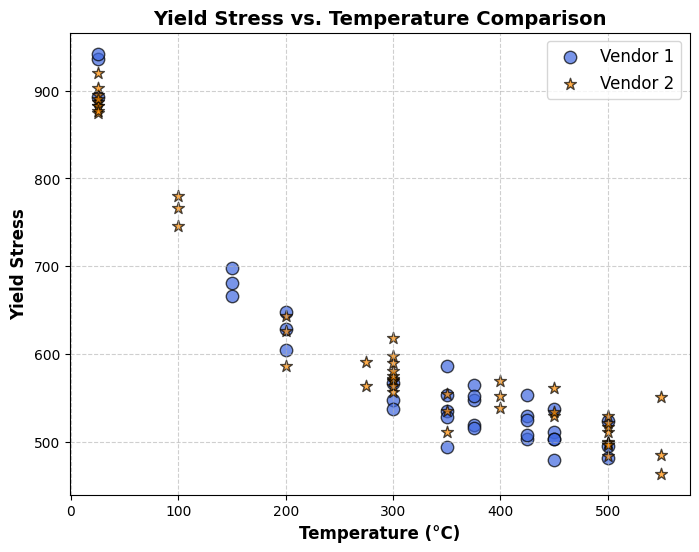

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(df_1["Temperature"], df_1["Mpa"], color='royalblue', edgecolors='black', alpha=0.7, s=80, label="Vendor 1")
plt.scatter(df_2["Temperature"], df_2["Mpa"], marker='*', color='darkorange', edgecolors='black', alpha=0.7, s=80, label="Vendor 2")

plt.xlabel("Temperature (°C)", fontsize=12, fontweight='bold')
plt.ylabel("Yield Stress", fontsize=12, fontweight='bold')
plt.title("Yield Stress vs. Temperature Comparison", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=12)

plt.show()

In [4]:
data = pd.concat([df_1, df_2], ignore_index=True)
data_sorted = data.sort_values(by="Temperature", ascending=True)
df_3 = data_sorted.reset_index(drop=True)
df_3.head(10)

,Temperature,YS,Mpa
0,25,1.04164,935.996871
1,25,1.04832,941.999386
2,25,0.99379,892.999818
3,25,0.97376,875.001261
4,25,0.98711,886.997304
5,25,0.98155,882.001199
6,25,0.99602,895.003652
7,25,0.99045,889.998561
8,25,1.00492,903.001014
9,25,1.02384,920.002147


In [5]:
df_dict = {temp: df_3[df_3["Temperature"] == temp].reset_index(drop=True) for temp in df_3["Temperature"].unique()}

df_dict[550]

,Temperature,YS,Mpa
0,550,0.61319,551.000270
1,550,0.51637,463.999755
2,550,0.53974,484.999569


In [6]:
# Arrhenius Transform
data_sorted['Inverse_Temp'] = 11604.53 / (data_sorted['Temperature'] + 273.16)  # Convert to Kelvin
data_sorted['Ln_Mpa'] = np.log(data_sorted['Mpa'])  # Log transformation

In [7]:
X_values = data_sorted['Inverse_Temp'].values
Y_values = data_sorted['Mpa'].values

In [8]:
def gamma_log_likelihood(params, x, y):
    shape = params[0]
    beta0 = params[1]
    beta1 = params[2]

    if shape <= 0:
        return np.inf

    scale = np.exp(beta0 + beta1 * x)
    return -np.sum(stats.gamma.logpdf(y, a=shape, scale=scale))

In [9]:
init_params = [2.0, np.log(np.mean(Y_values)), 0.0]
bounds = [(1e-6, None), (None, None), (None, None)]

result_gamma = optimize.minimize(
    gamma_log_likelihood,
    init_params,
    args=(X_values, Y_values),
    bounds=bounds,
    method='L-BFGS-B'
)

shape_gamma, beta0_gamma, beta1_gamma = result_gamma.x
print(f"[Gamma Fit] Shape: {shape_gamma:.4f}")


[Gamma Fit] Shape: 652.8495


In [10]:
scale = np.exp(beta0_gamma + beta1_gamma * X_values)
Y = np.log(scale)
X = data_sorted['Inverse_Temp'].values

X_mean = np.mean(X)
Y_mean = np.mean(Y)
w = np.sum((X - X_mean) * (Y - Y_mean)) / np.sum((X - X_mean)**2)
u = Y_mean - w * X_mean

print(f"Intercept (u): {u:.4f}")
print(f"Slope (w): {w:.4f}")

Intercept (u): -0.6201
Slope (w): 0.0241


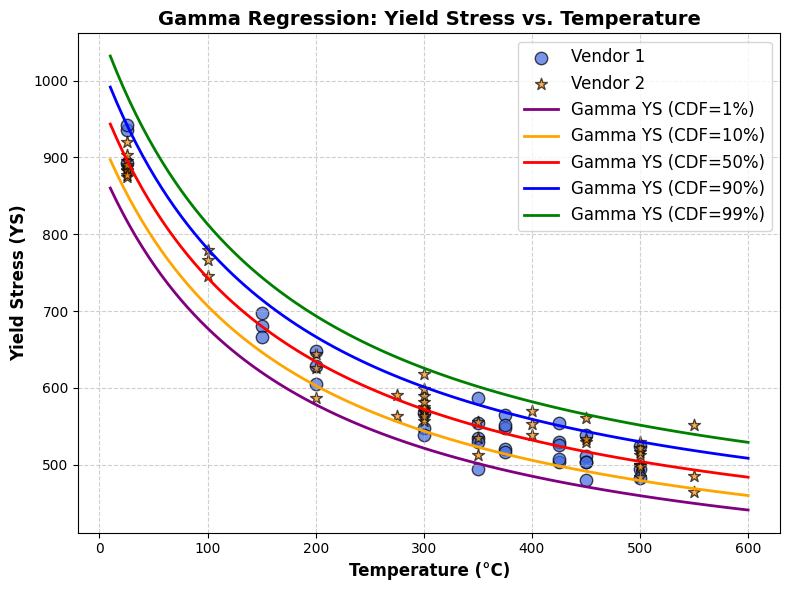

In [11]:
temperature_values = np.linspace(10, 600, 100)
inv_temp_range = 11604.53 / (temperature_values + 273.16)
scale_range = np.exp(u + w * inv_temp_range)

cdf_levels = {
    "CDF=1%": 0.01,
    "CDF=10%": 0.10,
    "CDF=50%": 0.50,
    "CDF=90%": 0.90,
    "CDF=99%": 0.99
}

ys_predictions = {
    label: stats.gamma.ppf(cdf, a=shape_gamma, scale=scale_range)
    for label, cdf in cdf_levels.items()
}

plt.figure(figsize=(8, 6))

plt.scatter(df_1["Temperature"], df_1["Mpa"], color='royalblue', edgecolors='black', s=80, alpha=0.7, label="Vendor 1")
plt.scatter(df_2["Temperature"], df_2["Mpa"], marker='*', color='darkorange', edgecolors='black', s=80, alpha=0.7, label="Vendor 2")

colors = ["purple", "orange", "red", "blue", "green"]
for (label, ys), color in zip(ys_predictions.items(), colors):
    plt.plot(temperature_values, ys, color=color, linewidth=2, label=f"Gamma YS ({label})")

plt.xlabel("Temperature (°C)", fontsize=12, fontweight="bold")
plt.ylabel("Yield Stress (YS)", fontsize=12, fontweight="bold")
plt.title("Gamma Regression: Yield Stress vs. Temperature", fontsize=14, fontweight="bold")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

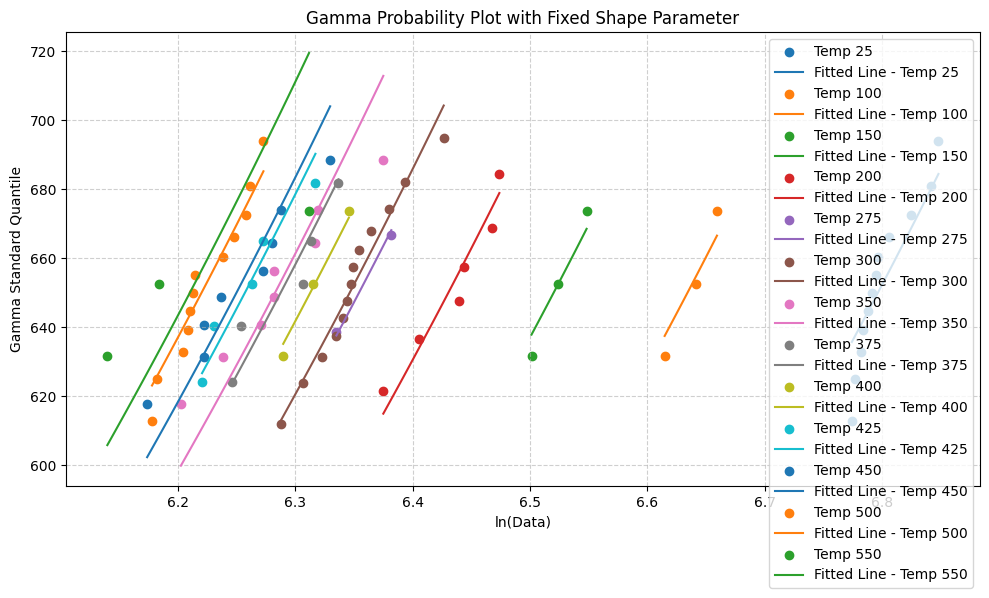

In [12]:
from scipy.stats import gamma

CONSTANT_SHAPE = shape_gamma

def median_rank(n, i):
    return (i - 0.3) / (n + 0.4)

plt.figure(figsize=(10, 6))

for temp in df_dict.keys():
    data = df_dict[temp]["Mpa"].values
    data = np.sort(data)

    n = len(data)
    p_values = np.array([median_rank(n, i + 1) for i in range(n)])

    # Estimate scale using fixed shape
    _, loc, scale = gamma.fit(data, floc=0, f0=CONSTANT_SHAPE)

    # Transform CDF to gamma variate space
    y_values = gamma.ppf(p_values, a=CONSTANT_SHAPE)
    x_values = np.log(data)

    plt.scatter(x_values, y_values, label=f"Temp {temp}")

    # Fitted line using MLE-estimated scale
    x_fit = np.linspace(min(data), max(data), 100)
    y_fit = gamma.ppf(gamma.cdf(x_fit, a=CONSTANT_SHAPE, scale=scale), a=CONSTANT_SHAPE)
    plt.plot(np.log(x_fit), y_fit, linestyle='-', label=f"Fitted Line - Temp {temp}")

plt.title("Gamma Probability Plot with Fixed Shape Parameter")
plt.xlabel("ln(Data)")
plt.ylabel("Gamma Standard Quantile")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()